In [ ]:
!pip install epyt_flow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.3/58.3 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 539.5/539.5 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 44.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 64.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.5/144.5 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.7/119.7 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.4/169.4 kB 9.9 MB/s eta 0:00:00
  Attempting uninstall: dill
    Found existing installation: dill 0.3.7
    Uninstalling dill-0.3.7:
      Successfully uninstalled dill-0.3.7
  Attempting uninstall: multiprocess
    Found existing installation: multiprocess 0.70.15
    Uninstalling multiprocess-0.70.15:
      Successfully uninstalled multiprocess-0.70.15
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behav

In [ ]:
import numpy as np
import pandas as pd
import os
from tqdm import tqdm
from IPython.display import display  

from epyt_flow.data.benchmarks import load_leakdb_scenarios
from epyt_flow.simulation import ScenarioSimulator, ToolkitConstants, ScenarioConfig
from epyt_flow.simulation.events import SpeciesInjectionEvent
from epyt_flow.utils import to_seconds

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


N_SCENARIOS = 200   
SIM_DAYS = 21       
ARSENIC_EVENT_MIN_DAYS = 1     
ARSENIC_EVENT_MAX_DAYS = 3     
ARSENIC_DOSE_RANGE = (50, 500) 
DATA_SAVE_DIR = "generated_dataset"
USE_NET1 = True     

def random_event(nodes, sim_days):
    """Generate random arsenic event parameters."""
    node_id = np.random.choice(nodes)
    event_duration = np.random.uniform(ARSENIC_EVENT_MIN_DAYS, ARSENIC_EVENT_MAX_DAYS)
    event_start = np.random.uniform(0, sim_days - event_duration)
    event_end = event_start + event_duration
    dose = np.random.uniform(*ARSENIC_DOSE_RANGE)
    return {
        "node_id": node_id,
        "start_day": event_start,
        "end_day": event_end,
        "dose_mg_per_L": dose,
        "species_id": "AsIII"
    }

def generate_scenario(sim_duration_days, all_nodes, cl_sensor_locations, flow_sensor_locations):
    """Generate one scenario config and event."""
    config, = load_leakdb_scenarios(scenarios_id=["1"], use_net1=USE_NET1)
    config = ScenarioConfig(scenario_config=config, f_msx_in="arsenic_contamination.msx")

    with ScenarioSimulator(scenario_config=config) as sim:
        sim.set_general_parameters(simulation_duration=to_seconds(days=sim_duration_days))
        sim.set_bulk_species_node_sensors({
            "Chlorine": cl_sensor_locations,
            "AsIII": cl_sensor_locations  # Ground truth at chlorine sensor nodes
        })
        sim.set_flow_sensors(flow_sensor_locations)  # Correct: flow sensors on link IDs

        
        event_params = random_event(all_nodes, sim_duration_days)
        arsenic_event = SpeciesInjectionEvent(
            species_id=event_params["species_id"],
            node_id=event_params["node_id"],
            profile=np.array([event_params["dose_mg_per_L"]]),
            source_type=ToolkitConstants.EN_MASS,
            start_time=int(event_params["start_day"] * 86400),
            end_time=int(event_params["end_day"] * 86400)
        )
        sim.add_system_event(arsenic_event)

        # Run simulation
        scada_data = sim.run_simulation()

        
        display(dir(scada_data))

       
        return {
            "chlorine": None,
            "flow": None,
            "arsenic_truth": None,
            "event_params": event_params,
            "scada_data": scada_data
        }

def main():
    os.makedirs(DATA_SAVE_DIR, exist_ok=True)
    config, = load_leakdb_scenarios(scenarios_id=["1"], use_net1=USE_NET1)
    tmp_sim = ScenarioSimulator(scenario_config=ScenarioConfig(scenario_config=config, f_msx_in="arsenic_contamination.msx"))
    all_nodes = tmp_sim.sensor_config.nodes
    all_links = tmp_sim.sensor_config.links

    cl_sensor_locations = ["10", "11", "12", "13", "21", "22", "23", "31", "32"]
    if len(all_links) >= 9:
        flow_sensor_locations = np.random.choice(all_links, size=9, replace=False).tolist()
    else:
        flow_sensor_locations = all_links
    tmp_sim.close()

    # For testing: generate a single scenario and inspect scada_data methods
    data = generate_scenario(SIM_DAYS, all_nodes, cl_sensor_locations, flow_sensor_locations)
    print("Event parameters:", data["event_params"])
    print("ScadaData methods:", dir(data["scada_data"]))


if __name__ == "__main__":
    main()

['_ScadaData__apply_global_sensor_noise',
 '_ScadaData__apply_sensor_reading_events',
 '_ScadaData__bulk_species_link_concentration_raw',
 '_ScadaData__bulk_species_node_concentration_raw',
 '_ScadaData__demand_data_raw',
 '_ScadaData__flow_data_raw',
 '_ScadaData__frozen_sensor_config',
 '_ScadaData__get_x_axis_label',
 '_ScadaData__init',
 '_ScadaData__link_quality_data_raw',
 '_ScadaData__map_sensor_to_idx',
 '_ScadaData__network_topo',
 '_ScadaData__node_quality_data_raw',
 '_ScadaData__pressure_data_raw',
 '_ScadaData__pumps_efficiency_data_raw',
 '_ScadaData__pumps_energy_usage_data_raw',
 '_ScadaData__pumps_state_data_raw',
 '_ScadaData__sensor_config',
 '_ScadaData__sensor_noise',
 '_ScadaData__sensor_reading_events',
 '_ScadaData__sensor_readings',
 '_ScadaData__sensor_readings_time',
 '_ScadaData__surface_species_concentration_raw',
 '_ScadaData__tanks_volume_data_raw',
 '_ScadaData__valves_state_data_raw',
 '_ScadaData__warnings_code',
 '__abstractmethods__',
 '__class__',
 

Event parameters: {'node_id': np.str_('31'), 'start_day': 0.3825392540387353, 'end_day': 2.7986844096308263, 'dose_mg_per_L': 486.45943347289744, 'species_id': 'AsIII'}
ScadaData methods: ['_ScadaData__apply_global_sensor_noise', '_ScadaData__apply_sensor_reading_events', '_ScadaData__bulk_species_link_concentration_raw', '_ScadaData__bulk_species_node_concentration_raw', '_ScadaData__demand_data_raw', '_ScadaData__flow_data_raw', '_ScadaData__frozen_sensor_config', '_ScadaData__get_x_axis_label', '_ScadaData__init', '_ScadaData__link_quality_data_raw', '_ScadaData__map_sensor_to_idx', '_ScadaData__network_topo', '_ScadaData__node_quality_data_raw', '_ScadaData__pressure_data_raw', '_ScadaData__pumps_efficiency_data_raw', '_ScadaData__pumps_energy_usage_data_raw', '_ScadaData__pumps_state_data_raw', '_ScadaData__sensor_config', '_ScadaData__sensor_noise', '_ScadaData__sensor_reading_events', '_ScadaData__sensor_readings', '_ScadaData__sensor_readings_time', '_ScadaData__surface_species

In [ ]:
import numpy as np
import pandas as pd
from epyt_flow.data.benchmarks import load_leakdb_scenarios
from epyt_flow.simulation import ScenarioSimulator, ScenarioConfig, ToolkitConstants
from epyt_flow.simulation.events import SpeciesInjectionEvent
from epyt_flow.utils import to_seconds

def run_arsenic_contamination_simulation():
    # Load base scenario config with arsenic MSX file
    config, = load_leakdb_scenarios(scenarios_id=["1"], use_net1=True)
    config = ScenarioConfig(scenario_config=config,
                            f_msx_in="arsenic_contamination.msx")

    with ScenarioSimulator(scenario_config=config) as sim:
        # Set simulation duration to 21 days
        sim.set_general_parameters(simulation_duration=to_seconds(days=21))

        # Define sensor locations
        cl_sensor_locations = ["10", "11", "12", "13", "21", "22", "23", "31", "32"]
        all_nodes = sim.sensor_config.nodes  
        flow_sensor_locations = sim.sensor_config.links  

        
        sim.set_bulk_species_node_sensors({"Chlorine": cl_sensor_locations,
                                           "AsIII": all_nodes})

        
        contamination_event = SpeciesInjectionEvent(
            species_id="AsIII",
            node_id="22",
            profile=np.array([100]),
            source_type=ToolkitConstants.EN_MASS,
            start_time=to_seconds(days=3),
            end_time=to_seconds(days=4)
        )
        sim.add_system_event(contamination_event)

        
        scada_data = sim.run_simulation()

        
        cl_df = pd.DataFrame(scada_data.get_data_bulk_species_node_concentration("Chlorine"))[cl_sensor_locations]
        asiii_df = pd.DataFrame(scada_data.get_data_bulk_species_node_concentration("AsIII"))[all_nodes]

        
        flow_data = scada_data.get_data_flows()
        # Only keep columns corresponding to flow_sensor_locations
        # Note: flow_data columns might correspond to sim.sensor_config.links
        link_ids = sim.sensor_config.links[:flow_data.shape[1]]  
        flow_df = pd.DataFrame(flow_data, columns=link_ids)
        flow_df = flow_df[flow_sensor_locations]

     
        return cl_df, asiii_df, flow_df

if __name__ == "__main__":
    chlorine_df, arsenic_df, flow_df = run_arsenic_contamination_simulation()
    print("Chlorine concentrations at sensors:\n", chlorine_df.head())
    print("\nArsenic concentrations at sensors:\n", arsenic_df.head())
    print("\nFlow sensor data:\n", flow_df.head())


TypeError: 'bulk_species_sensor_locations' must be an instance of 'dict' but not of '<class 'str'>'

In [ ]:
import numpy as np
import pandas as pd
from epyt_flow.data.benchmarks import load_leakdb_scenarios
from epyt_flow.simulation import ScenarioSimulator, ScenarioConfig, ToolkitConstants
from epyt_flow.simulation.events import SpeciesInjectionEvent
from epyt_flow.utils import to_seconds
from tqdm import tqdm
import os


NUM_SCENARIOS = 100
SIM_DAYS = 21
CONTAMINATION_DURATION_DAYS = 1  
CONTAMINATION_PROBABILITY = 0.5  
CONTAMINATION_STRENGTH_RANGE = (50, 200)  
CHLORINE_SENSOR_NODES = ["10", "11", "12", "13", "21", "22", "23", "31", "32"]
MSX_FILE = "arsenic_contamination.msx"  

# Output directories
OUTPUT_DATA_DIR = "simulation_outputs"
METADATA_CSV = "simulation_outputs/contamination_metadata.csv"
os.makedirs(OUTPUT_DATA_DIR, exist_ok=True)

def generate_arsenic_contamination_dataset():
  
    base_config_dict, = load_leakdb_scenarios(scenarios_id=["1"], use_net1=True)
    all_nodes = None

    metadata_records = []
    all_data = []

    for i in tqdm(range(NUM_SCENARIOS), desc="Generating scenarios"):
        # Create scenario config fresh each time to avoid side-effects
        config = ScenarioConfig(scenario_config=base_config_dict, f_msx_in=MSX_FILE)

        with ScenarioSimulator(scenario_config=config) as sim:
            sim.set_general_parameters(simulation_duration=to_seconds(days=SIM_DAYS))
            if all_nodes is None:
                all_nodes = sim.sensor_config.nodes

           
            sim.set_bulk_species_node_sensors({
                "Chlorine": CHLORINE_SENSOR_NODES,
                "AsIII": all_nodes
            })

           
            inject_contamination = np.random.rand() < CONTAMINATION_PROBABILITY

            if inject_contamination:
                event_node = np.random.choice(CHLORINE_SENSOR_NODES)
                event_strength = np.random.uniform(*CONTAMINATION_STRENGTH_RANGE)
                start_day = np.random.randint(1, SIM_DAYS - CONTAMINATION_DURATION_DAYS)

                contamination_event = SpeciesInjectionEvent(
                    species_id="AsIII",
                    node_id=event_node,
                    profile=np.array([event_strength]),
                    source_type=ToolkitConstants.EN_MASS,
                    start_time=to_seconds(days=start_day),
                    end_time=to_seconds(days=start_day + CONTAMINATION_DURATION_DAYS)
                )
                sim.add_system_event(contamination_event)
            else:
                event_node = None
                event_strength = None
                start_day = None

            # Run simulation
            scada_data = sim.run_simulation()

           
            df = scada_data.to_pandas_dataframe()

            # Add scenario and label info
            df["scenario"] = i
            df["label"] = int(inject_contamination)  
            df["event_node"] = event_node
            df["event_strength_mg_per_L"] = event_strength
            df["event_start_day"] = start_day

            # Append to full data list
            all_data.append(df)

            # Store metadata for this scenario
            metadata_records.append({
                "scenario": i,
                "event_occurred": int(inject_contamination),
                "event_node": event_node,
                "event_strength_mg_per_L": event_strength,
                "event_start_day": start_day
            })

            # Save individual scenario CSV (optional)
            df.to_csv(f"{OUTPUT_DATA_DIR}/scenario_{i:03d}.csv", index=False)

    
    full_dataset = pd.concat(all_data, ignore_index=True)
    full_dataset.to_csv(f"{OUTPUT_DATA_DIR}/arsenic_dataset_with_event_info.csv", index=False)
    print(f"Full dataset saved at {OUTPUT_DATA_DIR}/arsenic_dataset_with_event_info.csv")

    # Save metadata CSV
    metadata_df = pd.DataFrame(metadata_records)
    metadata_df.to_csv(METADATA_CSV, index=False)
    print(f"Metadata saved at {METADATA_CSV}")

if __name__ == "__main__":
    generate_arsenic_contamination_dataset()


Generating scenarios: 100%|██████████| 100/100 [04:02<00:00,  2.43s/it]
<ipython-input-34-4123736316>:98: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  full_dataset = pd.concat(all_data, ignore_index=True)


Full dataset saved at simulation_outputs/arsenic_dataset_with_event_info.csv
Metadata saved at simulation_outputs/contamination_metadata.csv


In [ ]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv("arsenic_dataset_with_event_info.csv")


cl_columns = [col for col in df.columns if col.startswith("Cl_Node_")]

# Function to detect anomalies using Z-score thresholding
def detect_anomalies_zscore(data, threshold=3.0):
    """
    data: pd.DataFrame with sensor readings (time x sensors)
    threshold: Z-score threshold for anomaly detection
    Returns: pd.Series boolean mask indicating anomaly presence at each timestamp
    """
   
    mean = data.mean()
    std = data.std()

    # Calculate Z-scores
    z_scores = (data - mean) / std

    
    anomaly_mask = (z_scores.abs() > threshold).any(axis=1)
    return anomaly_mask

# Process each scenario separately
results = []

for scenario_id, group in df.groupby("scenario"):
   
    cl_data = group[cl_columns]

    
    anomalies = detect_anomalies_zscore(cl_data, threshold=3.0)

    
    scenario_result = pd.DataFrame({
        "scenario": scenario_id,
        "time": group.index,  # Assuming time column exists, else index
        "anomaly_detected": anomalies.astype(int),
        "true_label": group["label"]  # 1 if contamination, else 0
    })
    results.append(scenario_result)


detection_results = pd.concat(results, ignore_index=True)


print(detection_results.groupby(["true_label", "anomaly_detected"]).size())


detection_results.to_csv("detection_results.csv", index=False)
print("Detection results saved to detection_results.csv")

true_label  anomaly_detected
0           0                   54486
1           0                   46414
dtype: int64
Detection results saved to detection_results.csv


✅ Detection results saved to simulation_outputs/detection_results.csv
✅ Best Case Scenario ID: 49
✅ Worst Case Scenario ID: 53


<ipython-input-44-658269256>:49: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  scenario_stats = merged.groupby("scenario", group_keys=False).apply(


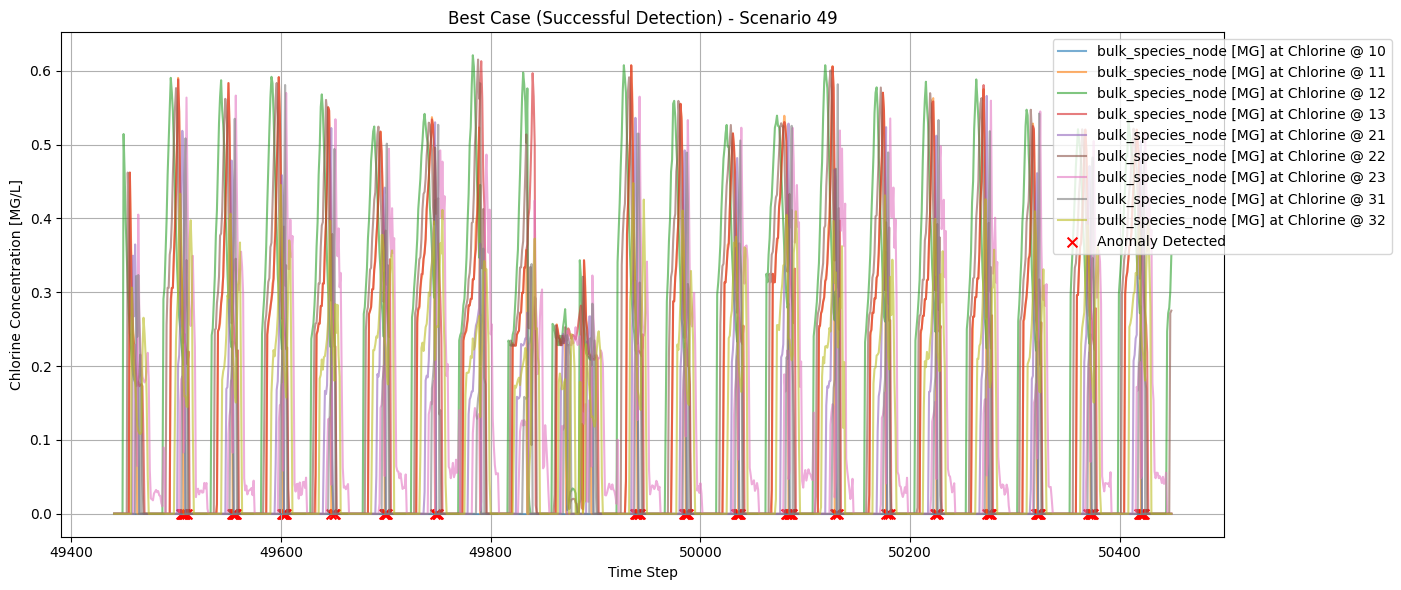

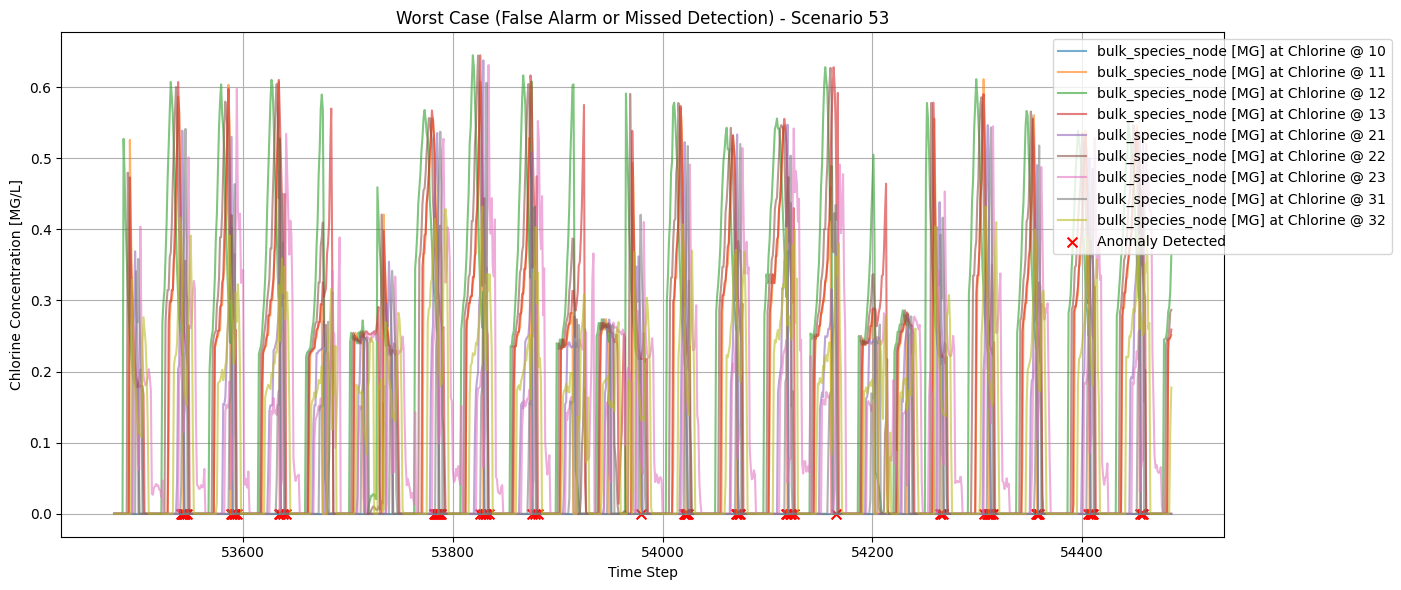

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os


df = pd.read_csv("simulation_outputs/arsenic_dataset_with_event_info.csv")


cl_columns = [col for col in df.columns if "bulk_species_node [MG] at Chlorine @" in col]
if not cl_columns:
    raise ValueError(" No chlorine sensor columns found. Check naming pattern.")


def detect_anomalies_zscore(data, threshold=3.0):
    mean = data.mean()
    std = data.std()
    z_scores = (data - mean) / std
    anomaly_mask = (z_scores.abs() > threshold).any(axis=1)
    return anomaly_mask


results = []
for scenario_id, group in df.groupby("scenario"):
    cl_data = group[cl_columns]
    anomalies = detect_anomalies_zscore(cl_data, threshold=3.0)

    scenario_result = pd.DataFrame({
        "scenario": scenario_id,
        "time": group.index,
        "anomaly_detected": anomalies.astype(int),
        "true_label": group["label"].values
    })
    results.append(scenario_result)

detection_results = pd.concat(results, ignore_index=True)


output_path = "simulation_outputs/detection_results.csv"
detection_results.to_csv(output_path, index=False)
print(f" Detection results saved to {output_path}")


merged = detection_results.copy()
merged["true_positive"] = ((merged["anomaly_detected"] == 1) & (merged["true_label"] == 1)).astype(int)
merged["false_positive"] = ((merged["anomaly_detected"] == 1) & (merged["true_label"] == 0)).astype(int)
merged["false_negative"] = ((merged["anomaly_detected"] == 0) & (merged["true_label"] == 1)).astype(int)

scenario_stats = merged.groupby("scenario", group_keys=False).apply(
    lambda x: pd.Series({
        "true_label": x["true_label"].iloc[0],
        "true_positive": x["true_positive"].sum(),
        "false_positive": x["false_positive"].sum(),
        "false_negative": x["false_negative"].sum()
    })
).reset_index()


if not scenario_stats[(scenario_stats["true_label"] == 1) & (scenario_stats["true_positive"] > 0)].empty:
    best_case_id = scenario_stats[(scenario_stats["true_label"] == 1) & (scenario_stats["true_positive"] > 0)] \
        .sort_values("true_positive", ascending=False).iloc[0]["scenario"]
    print(f" Best Case Scenario ID: {int(best_case_id)}")
else:
    best_case_id = None
    print(" No successful contamination detection found (no best case).")

if not scenario_stats[(scenario_stats["false_positive"] > 0) | (scenario_stats["false_negative"] > 0)].empty:
    worst_case_id = scenario_stats[(scenario_stats["false_positive"] > 0) | (scenario_stats["false_negative"] > 0)] \
        .sort_values(["false_positive", "false_negative"], ascending=False).iloc[0]["scenario"]
    print(f" Worst Case Scenario ID: {int(worst_case_id)}")
else:
    worst_case_id = None
    print(" No clear worst case found.")

# --- Plotting Function ---
def plot_scenario(scenario_id, title):
    scenario_df = df[df["scenario"] == scenario_id].copy()
    cl_data = scenario_df[cl_columns]
    anomaly_flags = detect_anomalies_zscore(cl_data).astype(int)

    plt.figure(figsize=(14, 6))
    for col in cl_columns:
        plt.plot(cl_data.index, cl_data[col], label=col, alpha=0.6)

    anomaly_indices = cl_data.index[anomaly_flags == 1]
    if not anomaly_indices.empty:
        plt.scatter(anomaly_indices, cl_data.loc[anomaly_indices, cl_columns[0]],
                    color='red', label='Anomaly Detected', marker='x', s=50)

    plt.title(f"{title} - Scenario {scenario_id}")
    plt.xlabel("Time Step")
    plt.ylabel("Chlorine Concentration [MG/L]")
    plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1))
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# --- Plot best and worst case ---
if best_case_id is not None:
    plot_scenario(int(best_case_id), "Best Case (Successful Detection)")

if worst_case_id is not None:
    plot_scenario(int(worst_case_id), "Worst Case (False Alarm or Missed Detection)")


In [43]:
print(df.columns.tolist())

['pressure [meter] at 10', 'pressure [meter] at 11', 'pressure [meter] at 12', 'pressure [meter] at 13', 'pressure [meter] at 21', 'pressure [meter] at 22', 'pressure [meter] at 23', 'pressure [meter] at 31', 'pressure [meter] at 32', 'pressure [meter] at 9', 'pressure [meter] at 2', 'flow [cubic meter/hr] at 10', 'flow [cubic meter/hr] at 11', 'flow [cubic meter/hr] at 12', 'flow [cubic meter/hr] at 21', 'flow [cubic meter/hr] at 22', 'flow [cubic meter/hr] at 31', 'flow [cubic meter/hr] at 110', 'flow [cubic meter/hr] at 111', 'flow [cubic meter/hr] at 112', 'flow [cubic meter/hr] at 113', 'flow [cubic meter/hr] at 121', 'flow [cubic meter/hr] at 122', 'flow [cubic meter/hr] at 9', 'bulk_species_node [MG] at Chlorine @ 10', 'bulk_species_node [MG] at Chlorine @ 11', 'bulk_species_node [MG] at Chlorine @ 12', 'bulk_species_node [MG] at Chlorine @ 13', 'bulk_species_node [MG] at Chlorine @ 21', 'bulk_species_node [MG] at Chlorine @ 22', 'bulk_species_node [MG] at Chlorine @ 23', 'bulk_